# Diabetes Lab Results Analysis
### Data cleaning, exploratory analysis and a logistic-regression risk model on the Pima Indians Diabetes dataset

**Project 1 of the Health Data Analytics portfolio**

---

## 1. Problem statement

Type 2 diabetes is one of the most common chronic conditions seen in primary care, and much of its burden is
preventable when high-risk patients are identified early and enrolled in lifestyle or pharmacological
prevention programmes. Clinics routinely collect the measurements needed to estimate that risk (glucose,
BMI, blood pressure, age, family history) but rarely turn them into a systematic risk score.

This notebook asks three questions a health-analytics team would ask of a screening dataset:

1. **Data quality:** are the lab values fit for analysis, and how should missing or implausible readings be handled?
2. **Clinical patterns:** which measurements separate patients who go on to be diagnosed with diabetes from those who do not?
3. **Risk stratification:** can a simple, interpretable model rank patients into low / moderate / high risk tiers that a clinic could act on?

### The dataset

The Pima Indians Diabetes dataset (originally from the US National Institute of Diabetes and Digestive and Kidney
Diseases) contains 768 female patients aged 21+ of Pima Indian heritage, with eight clinical measurements and a
binary outcome indicating whether the patient was diagnosed with diabetes within five years of the measurements.

| Column | Clinical meaning | Units |
|---|---|---|
| `Pregnancies` | Number of times pregnant | count |
| `Glucose` | Plasma glucose concentration at 2 h in an oral glucose tolerance test | mg/dL |
| `BloodPressure` | Diastolic blood pressure | mm Hg |
| `SkinThickness` | Triceps skin-fold thickness (adiposity proxy) | mm |
| `Insulin` | 2-hour serum insulin | mu U/mL |
| `BMI` | Body mass index | kg/m² |
| `DiabetesPedigreeFunction` | Score summarising diabetes history in relatives | score |
| `Age` | Age | years |
| `Outcome` | Diabetes diagnosis within 5 years (1 = yes) | binary |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, brier_score_loss)
import statsmodels.api as sm

RANDOM_STATE = 42
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# --- Chart theme: one teal for "no diabetes", one warm orange for "diabetes", recessive chrome ---
TEAL, ORANGE, NAVY = "#0f9d8a", "#e8892b", "#0b1f3a"
INK, MUTED, GRID = "#1f2933", "#52606d", "#e4e7eb"
OUTCOME_COLORS = {0: TEAL, 1: ORANGE}
OUTCOME_LABELS = {0: "No diabetes", 1: "Diabetes"}

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight", "font.size": 10.5,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "axes.titlecolor": INK, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})

def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / name)
    plt.show()

## 2. Load and inspect the raw data

In [2]:
df = pd.read_csv("data/diabetes.csv")
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}   Duplicate rows: {df.duplicated().sum()}")
df.head()

Rows: 768   Columns: 9   Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


Two things stand out immediately in the summary table:

* The **minimum of `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI` is 0**. A living patient cannot have
  a plasma glucose of 0 mg/dL or a BMI of 0, so these zeros are not measurements. They are missing values that were
  recorded as 0 in the original file.
* `Pregnancies` and `Outcome` legitimately contain zeros, so they are left alone.

Treating those zeros as real numbers would drag the means down and, more importantly, would teach a model that
"BMI = 0" is a strong predictor of *not* having diabetes. The first cleaning task is to quantify and recode them.

## 3. Data cleaning

In [4]:
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_audit = pd.DataFrame({
    "zeros": (df[ZERO_AS_MISSING] == 0).sum(),
    "pct_of_rows": ((df[ZERO_AS_MISSING] == 0).mean() * 100).round(1),
}).sort_values("zeros", ascending=False)
zero_audit

,zeros,pct_of_rows
Insulin,374,48.7
SkinThickness,227,29.6
BloodPressure,35,4.6
BMI,11,1.4
Glucose,5,0.7


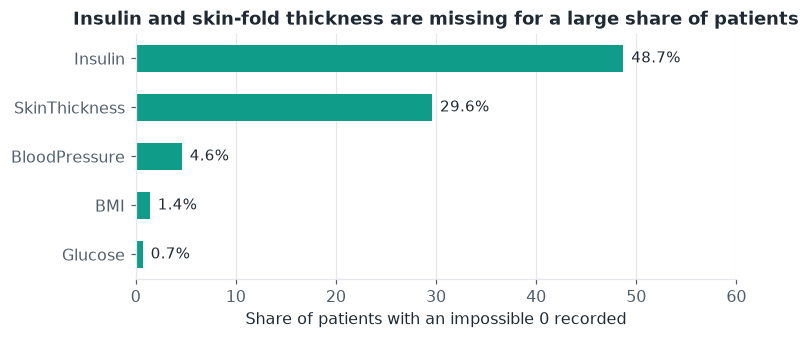

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
audit = zero_audit.sort_values("pct_of_rows")
bars = ax.barh(audit.index, audit.pct_of_rows, color=TEAL, height=0.55)
for b, v in zip(bars, audit.pct_of_rows):
    ax.text(v + 0.8, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", color=INK, fontsize=10)
ax.set_xlim(0, 60); ax.set_xlabel("Share of patients with an impossible 0 recorded")
ax.set_title("Insulin and skin-fold thickness are missing for a large share of patients")
ax.grid(axis="y", visible=False)
finish(fig, "01_missing_zeros.png")

In [6]:
clean = df.copy()
clean[ZERO_AS_MISSING] = clean[ZERO_AS_MISSING].replace(0, np.nan)

print(f"Complete cases after recoding zeros: {clean.dropna().shape[0]} of {len(clean)} "
      f"({clean.dropna().shape[0] / len(clean):.0%})")

# Is missingness related to the outcome? If it were strongly related, dropping rows would bias the analysis.
(clean.groupby("Outcome")[ZERO_AS_MISSING].apply(lambda g: g.isna().mean() * 100)
      .round(1).rename(index=OUTCOME_LABELS).T
      .rename(columns=lambda c: f"% missing – {c}"))

Complete cases after recoding zeros: 392 of 768 (51%)


Outcome,% missing – No diabetes,% missing – Diabetes
Glucose,0.6,0.7
BloodPressure,3.8,6.0
SkinThickness,27.8,32.8
Insulin,47.2,51.5
BMI,1.8,0.7


### Cleaning decisions

| Issue | Decision | Rationale |
|---|---|---|
| Zeros in five lab columns | Recode to `NaN` | Physiologically impossible; they are missing, not measured. |
| `Insulin` 48.7 % missing, `SkinThickness` 29.6 % missing | **Keep the columns, impute** rather than drop rows | Dropping incomplete rows would discard half the cohort (only 392 complete cases) and the missingness is only mildly related to outcome, so imputation is the lower-bias choice. |
| Imputation method | **Median**, fitted on the training split only inside the model pipeline | Robust to the right-skew in `Insulin`; fitting inside the pipeline prevents leakage from the test set. |
| Duplicates / outliers | None removed | No duplicate rows; extreme values (e.g. insulin > 600) are clinically plausible in insulin-resistant patients. |

For the descriptive EDA below a simple overall median imputation is used so that every chart is based on the
full 768 patients. The model section re-does the imputation properly inside a cross-validated pipeline.

In [7]:
eda = clean.copy()
for col in ZERO_AS_MISSING:
    eda[col] = eda[col].fillna(eda[col].median())
eda.isna().sum().sum()

np.int64(0)

## 4. Exploratory data analysis

### 4.1 How common is diabetes in this cohort?

268 of 768 patients (34.9%) were diagnosed with diabetes within five years.


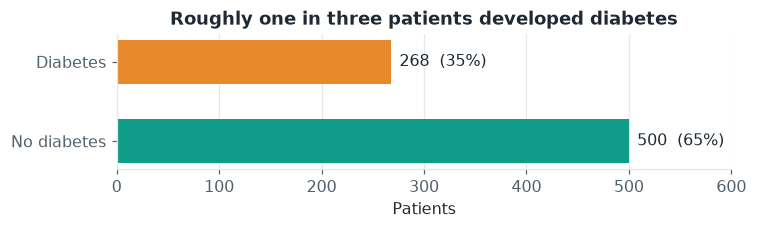

In [8]:
counts = df.Outcome.value_counts().sort_index()
prevalence = df.Outcome.mean()
print(f"{counts[1]} of {len(df)} patients ({prevalence:.1%}) were diagnosed with diabetes within five years.")

fig, ax = plt.subplots(figsize=(7, 2.2))
bars = ax.barh([OUTCOME_LABELS[k] for k in counts.index], counts.values,
               color=[OUTCOME_COLORS[k] for k in counts.index], height=0.55)
for b, v in zip(bars, counts.values):
    ax.text(v + 8, b.get_y() + b.get_height() / 2, f"{v}  ({v / len(df):.0%})", va="center", color=INK)
ax.set_xlim(0, 600); ax.grid(axis="y", visible=False); ax.set_xlabel("Patients")
ax.set_title("Roughly one in three patients developed diabetes")
finish(fig, "02_outcome_balance.png")

A 35 % positive rate is far higher than the population prevalence of type 2 diabetes (roughly 10 % in the US),
reflecting the very high risk in this population. It also means the classes are **moderately imbalanced**: a model that
predicts "no diabetes" for everyone would already be 65 % accurate, so accuracy alone is not a useful metric.
Sensitivity, specificity and AUC are reported instead.

### 4.2 Which measurements differ between the two groups?

In [9]:
summary = (eda.groupby("Outcome").median().T.rename(columns=OUTCOME_LABELS).round(2))
summary["difference"] = (summary["Diabetes"] - summary["No diabetes"]).round(2)
summary

Outcome,No diabetes,Diabetes,difference
Pregnancies,2.00,4.00,2.00
Glucose,107.50,140.00,32.50
BloodPressure,72.00,74.00,2.00
SkinThickness,29.00,29.00,0.00
Insulin,125.00,125.00,0.00
BMI,30.40,34.25,3.85
DiabetesPedigreeFunction,0.34,0.45,0.11
Age,27.00,36.00,9.00


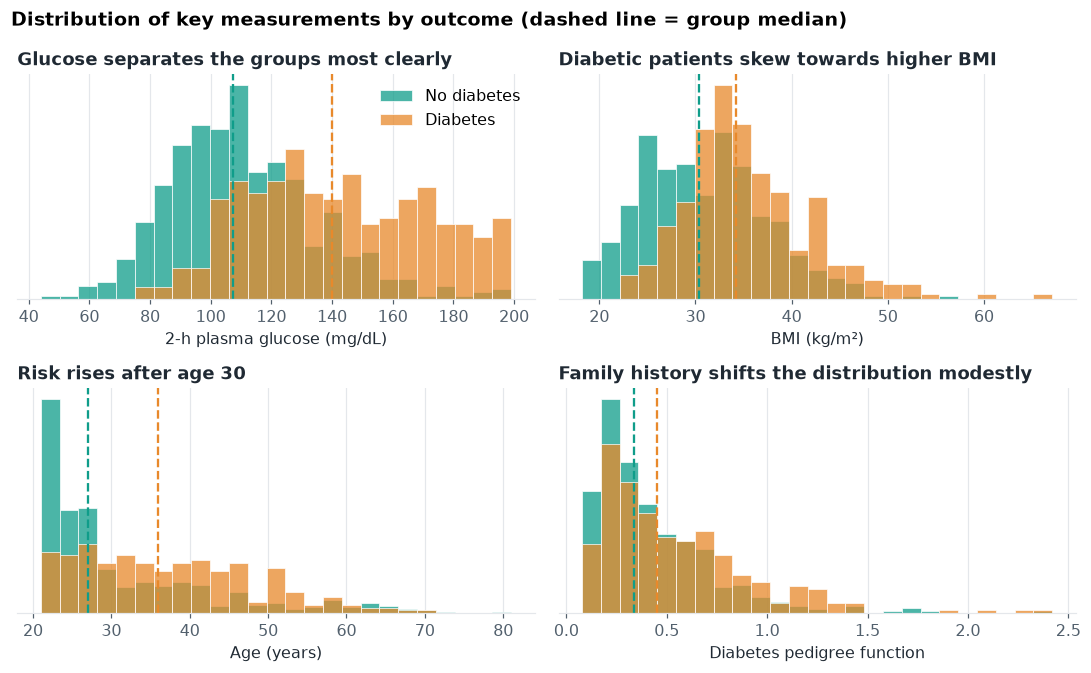

In [10]:
key_vars = [("Glucose", "2-h plasma glucose (mg/dL)"), ("BMI", "BMI (kg/m²)"),
            ("Age", "Age (years)"), ("DiabetesPedigreeFunction", "Diabetes pedigree function")]
fig, axes = plt.subplots(2, 2, figsize=(10, 6.2))
for ax, (col, label) in zip(axes.ravel(), key_vars):
    bins = np.histogram_bin_edges(eda[col], bins=25)
    for k in (0, 1):
        ax.hist(eda.loc[eda.Outcome == k, col], bins=bins, density=True, alpha=0.75,
                color=OUTCOME_COLORS[k], label=OUTCOME_LABELS[k], edgecolor="white", linewidth=0.6)
        ax.axvline(eda.loc[eda.Outcome == k, col].median(), color=OUTCOME_COLORS[k], lw=1.5, ls="--")
    ax.set_xlabel(label); ax.set_yticks([]); ax.grid(axis="y", visible=False); ax.spines["left"].set_visible(False)
axes[0, 0].legend(loc="upper right")
axes[0, 0].set_title("Glucose separates the groups most clearly", loc="left")
axes[0, 1].set_title("Diabetic patients skew towards higher BMI", loc="left")
axes[1, 0].set_title("Risk rises after age 30", loc="left")
axes[1, 1].set_title("Family history shifts the distribution modestly", loc="left")
fig.suptitle("Distribution of key measurements by outcome (dashed line = group median)", fontweight="bold", x=0.01, ha="left")
finish(fig, "03_distributions_by_outcome.png")

**Clinical read-out.** The median 2-hour glucose is 140 mg/dL in patients who developed diabetes versus 107.5 mg/dL in
those who did not, a gap of more than 30 mg/dL. A 2-hour OGTT value of 140–199 mg/dL is the standard definition of
impaired glucose tolerance, so the "diabetes" group median sits exactly at the pre-diabetic threshold. BMI shows a
smaller but consistent shift (34.3 vs 30.4 kg/m²; both groups are on average obese). Age and family history
(pedigree function) shift the distributions modestly; blood pressure, insulin and skin-fold thickness barely differ
at the median.

### 4.3 Prevalence across clinically meaningful bands

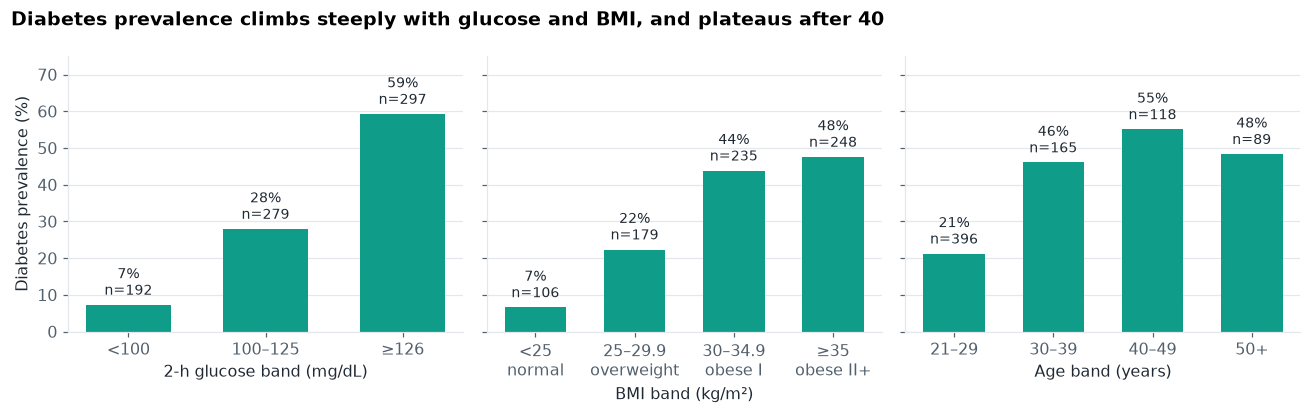

prevalence    n
GlucoseBand <100                        7.3  192
            100–125                    28.0  279
            ≥126                       59.3  297
BMIBand     <25\nnormal                 6.6  106
            25–29.9\noverweight        22.3  179
            30–34.9\nobese I           43.8  235
            ≥35\nobese II+             47.6  248
AgeBand     21–29                      21.2  396
            30–39                      46.1  165
            40–49                      55.1  118
            50+                        48.3   89

In [11]:
eda["GlucoseBand"] = pd.cut(eda.Glucose, [0, 99, 125, 400], labels=["<100", "100–125", "≥126"])
eda["BMIBand"] = pd.cut(eda.BMI, [0, 24.9, 29.9, 34.9, 100], labels=["<25\nnormal", "25–29.9\noverweight", "30–34.9\nobese I", "≥35\nobese II+"])
eda["AgeBand"] = pd.cut(eda.Age, [20, 29, 39, 49, 100], labels=["21–29", "30–39", "40–49", "50+"])

band_tables = {}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, (col, title) in zip(axes, [("GlucoseBand", "2-h glucose band (mg/dL)"),
                                   ("BMIBand", "BMI band (kg/m²)"), ("AgeBand", "Age band (years)")]):
    g = eda.groupby(col, observed=True).Outcome.agg(prevalence="mean", n="size")
    band_tables[col] = g
    bars = ax.bar(g.index.astype(str), g.prevalence * 100, color=TEAL, width=0.62)
    for b, (p, n) in zip(bars, zip(g.prevalence, g.n)):
        ax.text(b.get_x() + b.get_width() / 2, p * 100 + 1.5, f"{p:.0%}\nn={n}", ha="center", va="bottom", fontsize=9, color=INK)
    ax.set_xlabel(title); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Diabetes prevalence (%)"); axes[0].set_ylim(0, 75)
fig.suptitle("Diabetes prevalence climbs steeply with glucose and BMI, and plateaus after 40",
             fontweight="bold", x=0.01, ha="left")
finish(fig, "04_prevalence_by_band.png")

pd.concat(band_tables, axis=0).assign(prevalence=lambda d: (d.prevalence * 100).round(1))

**Actionable pattern.** Prevalence rises from 7 % in patients with a 2-hour glucose under 100 mg/dL to 59 % at or above
126 mg/dL, an eight-fold gradient. BMI shows a similar dose-response: 7 % in normal-weight patients versus 44–48 % in
the obese bands. These two variables alone would let a clinic triage most of the cohort, and both are cheap to measure.

### 4.4 Correlation structure

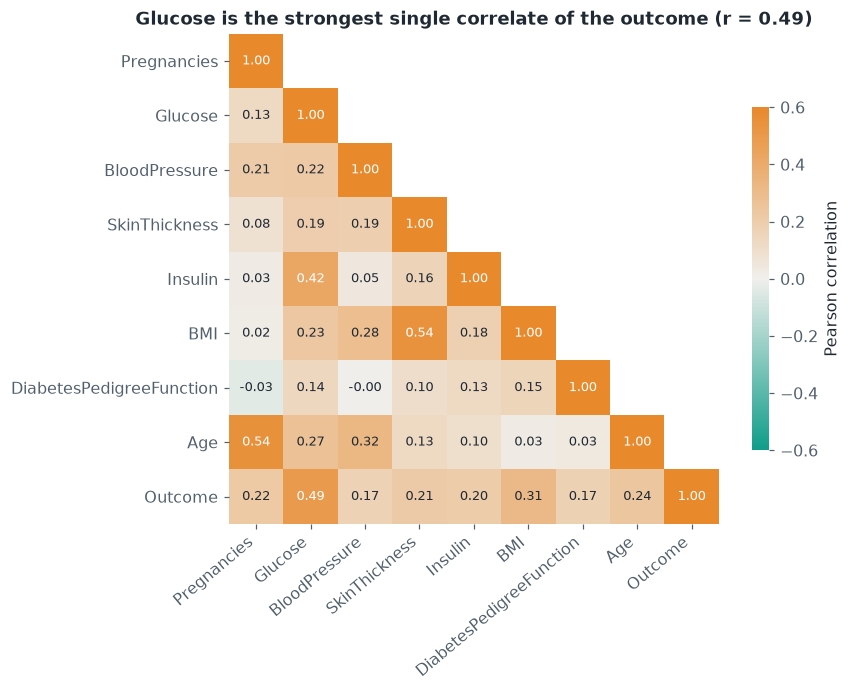

,corr_with_outcome
Glucose,0.493
BMI,0.312
Age,0.238
Pregnancies,0.222
SkinThickness,0.215
Insulin,0.204
DiabetesPedigreeFunction,0.174
BloodPressure,0.166


In [12]:
from matplotlib.colors import LinearSegmentedColormap
diverging = LinearSegmentedColormap.from_list("teal_gray_orange", [TEAL, "#f0efec", ORANGE])

corr = eda[df.columns].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8.2, 6.4))
im = ax.imshow(np.where(mask, np.nan, corr), cmap=diverging, vmin=-0.6, vmax=0.6)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=40, ha="right"); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(i + 1):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(v) > 0.4 else INK)
ax.grid(False); ax.spines[:].set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.7); cb.set_label("Pearson correlation"); cb.outline.set_visible(False)
ax.set_title("Glucose is the strongest single correlate of the outcome (r = 0.49)")
finish(fig, "05_correlation_heatmap.png")

corr["Outcome"].drop("Outcome").sort_values(ascending=False).round(3).to_frame("corr_with_outcome")

The correlation matrix confirms the ordering seen in the distributions (glucose 0.49, BMI 0.31, age 0.24) and
flags one pair of related predictors worth remembering when reading the model: `Age` and `Pregnancies` are correlated
(r = 0.54), so their individual coefficients partly share the same signal. No pair is collinear enough to be a
problem for logistic regression.

## 5. Logistic-regression risk model

Logistic regression is chosen deliberately over more flexible models. In a clinical setting an interpretable score
whose coefficients can be explained to a clinician (*"each 30 mg/dL of glucose roughly triples the odds"*) is far more
likely to be adopted than a black box, and on a dataset of this size its discrimination is competitive with tree
ensembles.

**Protocol**

* Stratified 75 / 25 train–test split (576 / 192 patients), test set held out until the end.
* Pipeline: median imputation → standardisation → L2-regularised logistic regression. Imputation and scaling are
  fitted on training folds only, so no information leaks from the test set.
* 5-fold stratified cross-validation on the training set to estimate out-of-sample AUC before touching the test set.

In [13]:
FEATURES = [c for c in df.columns if c != "Outcome"]
X, y = clean[FEATURES], clean["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, C=1.0)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"Train / test size: {len(X_train)} / {len(X_test)}")
print(f"5-fold CV AUC on training set: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

model.fit(X_train, y_train)
proba_test = model.predict_proba(X_test)[:, 1]
print(f"Held-out test AUC: {roc_auc_score(y_test, proba_test):.3f}")
print(f"Brier score (lower is better; 0.228 = predicting the base rate): {brier_score_loss(y_test, proba_test):.3f}")

Train / test size: 576 / 192
5-fold CV AUC on training set: 0.831 ± 0.023
Held-out test AUC: 0.824
Brier score (lower is better; 0.228 = predicting the base rate): 0.170


### 5.1 Discrimination: ROC curve

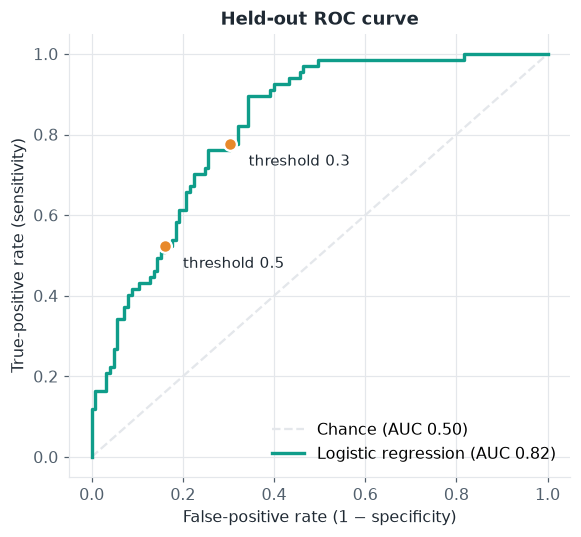

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, proba_test)
auc = roc_auc_score(y_test, proba_test)

fig, ax = plt.subplots(figsize=(5.4, 5))
ax.plot([0, 1], [0, 1], color=GRID, lw=1.5, ls="--", label="Chance (AUC 0.50)")
ax.plot(fpr, tpr, color=TEAL, lw=2.2, label=f"Logistic regression (AUC {auc:.2f})")
for thr in (0.5, 0.3):
    idx = np.argmin(np.abs(thresholds - thr))
    ax.scatter(fpr[idx], tpr[idx], s=70, color=ORANGE, zorder=5, edgecolor="white", linewidth=1.5)
    ax.annotate(f"threshold {thr}", (fpr[idx], tpr[idx]), xytext=(12, -14), textcoords="offset points", color=INK, fontsize=9.5)
ax.set_xlabel("False-positive rate (1 − specificity)"); ax.set_ylabel("True-positive rate (sensitivity)")
ax.set_title("Held-out ROC curve"); ax.legend(loc="lower right")
finish(fig, "06_roc_curve.png")

### 5.2 What drives the score? Odds ratios per standard deviation

In [15]:
# Refit the same standardised design with statsmodels to obtain confidence intervals.
X_train_std = model[:-1].transform(X_train)
sm_fit = sm.Logit(y_train.values, sm.add_constant(X_train_std)).fit(disp=0)
ci = np.asarray(sm_fit.conf_int())
odds = (pd.DataFrame({"feature": FEATURES,
                      "odds_ratio_per_SD": np.exp(np.asarray(sm_fit.params)[1:]),
                      "ci_low": np.exp(ci[1:, 0]), "ci_high": np.exp(ci[1:, 1]),
                      "p_value": np.asarray(sm_fit.pvalues)[1:],
                      "one_SD_equals": [X_train[f].std() for f in FEATURES]})
          .sort_values("odds_ratio_per_SD"))
odds.round(3).set_index("feature")

,odds_ratio_per_SD,ci_low,ci_high,p_value,one_SD_equals
feature,,,,,
SkinThickness,0.935,0.722,1.211,0.609,10.465
BloodPressure,0.937,0.738,1.191,0.596,12.514
Insulin,0.960,0.757,1.218,0.739,107.424
Age,1.132,0.883,1.452,0.329,11.879
DiabetesPedigreeFunction,1.240,0.992,1.551,0.059,0.333
Pregnancies,1.570,1.223,2.015,0.000,3.313
BMI,2.103,1.588,2.787,0.000,6.795
Glucose,3.276,2.492,4.307,0.000,30.226


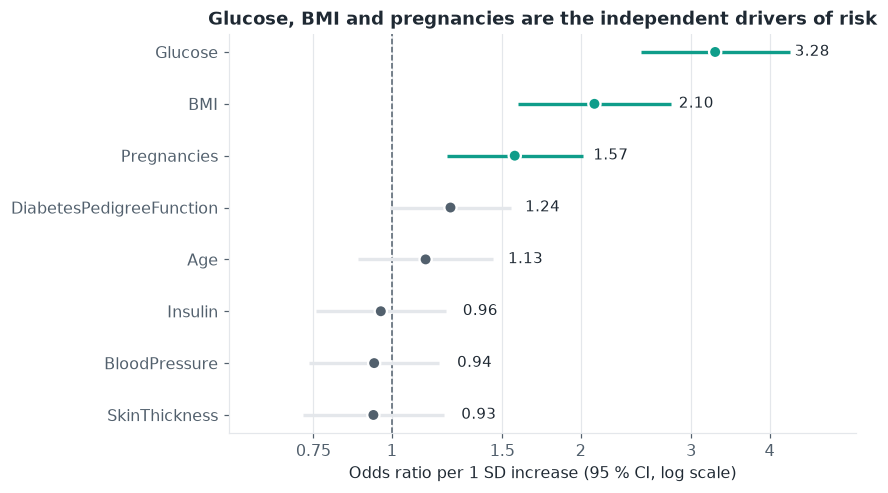

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ypos = np.arange(len(odds))
sig = odds.p_value < 0.05
ax.axvline(1, color=MUTED, lw=1, ls="--")
ax.hlines(ypos, odds.ci_low, odds.ci_high, color=np.where(sig, TEAL, GRID), lw=2.2)
ax.scatter(odds.odds_ratio_per_SD, ypos, s=64, color=np.where(sig, TEAL, MUTED), zorder=5, edgecolor="white", linewidth=1.5)
for yv, (o, hi) in enumerate(zip(odds.odds_ratio_per_SD, odds.ci_high)):
    ax.text(hi + 0.08, yv, f"{o:.2f}", va="center", color=INK, fontsize=9.5)
ax.set_yticks(ypos); ax.set_yticklabels(odds.feature)
ax.set_xscale("log"); ax.set_xticks([0.75, 1, 1.5, 2, 3, 4]); ax.set_xticklabels(["0.75", "1", "1.5", "2", "3", "4"])
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_xlim(0.55, 5.5); ax.set_xlabel("Odds ratio per 1 SD increase (95 % CI, log scale)"); ax.grid(axis="y", visible=False)
ax.set_title("Glucose, BMI and pregnancies are the independent drivers of risk")
finish(fig, "07_odds_ratios.png")

**How to read this.** Each odds ratio is the multiplicative change in the odds of diabetes for a one-standard-deviation
increase in that measurement, holding the others constant:

* **Glucose** (1 SD ≈ 30 mg/dL): OR 3.3 (95 % CI 2.5–4.3). By far the dominant driver, and consistent with glucose
  being the diagnostic criterion itself.
* **BMI** (1 SD ≈ 6.8 kg/m²): OR 2.1 (1.6–2.8). Adiposity contributes independently of glucose.
* **Pregnancies** (1 SD ≈ 3.3): OR 1.6 (1.2–2.0). Likely capturing gestational-diabetes history and age effects.
* **Pedigree function** (family history): OR 1.2, borderline (p ≈ 0.06).
* **Age**, once glucose, BMI and pregnancies are known, adds little (OR 1.1, CI crosses 1) even though it was strongly
  associated on its own. The crude age gradient in section 4.3 is largely explained by glucose and BMI rising with age.
* **Blood pressure, insulin and skin-fold** carry no independent signal here (all CIs straddle 1).

### 5.3 Choosing an operating threshold

The default 0.5 cut-off optimises accuracy, but for a **screening** use-case the cost of a missed case (a patient who
progresses undetected) is higher than the cost of a false alarm (an extra HbA1c test and a lifestyle conversation).
The table below shows how the trade-off moves as the threshold is lowered.

In [17]:
def metrics_at(threshold):
    pred = (proba_test >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {"threshold": threshold, "flagged_%": pred.mean() * 100, "sensitivity": tp / (tp + fn),
            "specificity": tn / (tn + fp), "precision (PPV)": tp / (tp + fp), "accuracy": accuracy_score(y_test, pred),
            "F1": f1_score(y_test, pred), "missed_cases": fn, "false_alarms": fp}

threshold_table = pd.DataFrame([metrics_at(t) for t in (0.5, 0.4, 0.35, 0.3, 0.25, 0.2)]).set_index("threshold")
threshold_table.round(3)

,flagged_%,sensitivity,specificity,precision (PPV),accuracy,F1,missed_cases,false_alarms
threshold,,,,,,,,
0.50,28.125,0.507,0.840,0.630,0.724,0.562,33,20
0.40,34.375,0.612,0.800,0.621,0.734,0.617,26,25
0.35,38.542,0.687,0.776,0.622,0.745,0.652,21,28
0.30,47.396,0.776,0.688,0.571,0.719,0.658,15,39
0.25,51.562,0.836,0.656,0.566,0.719,0.675,11,43
0.20,55.729,0.896,0.624,0.561,0.719,0.690,7,47


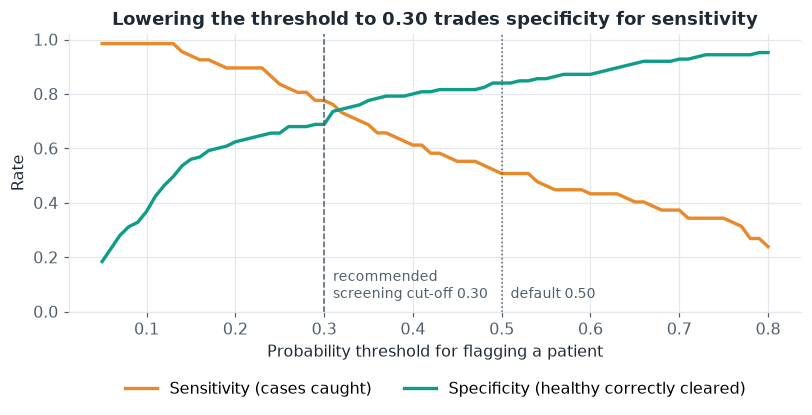

In [18]:
grid = np.linspace(0.05, 0.8, 76)
sens = [((proba_test >= t) & (y_test == 1)).sum() / (y_test == 1).sum() for t in grid]
spec = [((proba_test < t) & (y_test == 0)).sum() / (y_test == 0).sum() for t in grid]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(grid, sens, color=ORANGE, lw=2.2, label="Sensitivity (cases caught)")
ax.plot(grid, spec, color=TEAL, lw=2.2, label="Specificity (healthy correctly cleared)")
ax.axvline(0.3, color=MUTED, lw=1, ls="--"); ax.text(0.31, 0.05, "recommended\nscreening cut-off 0.30", color=MUTED, fontsize=9)
ax.axvline(0.5, color=MUTED, lw=1, ls=":"); ax.text(0.51, 0.05, "default 0.50", color=MUTED, fontsize=9)
ax.set_xlabel("Probability threshold for flagging a patient"); ax.set_ylabel("Rate"); ax.set_ylim(0, 1.02)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
ax.set_title("Lowering the threshold to 0.30 trades specificity for sensitivity")
finish(fig, "08_threshold_tradeoff.png")

At the **0.30 threshold** the model catches 78 % of future diabetes cases (vs 51 % at 0.50) while still clearing
69 % of patients who will not develop the disease. It flags 47 % of the cohort for follow-up, which is a workable
load for a targeted prevention programme in a population with 35 % prevalence.

### 5.4 Calibration: are the probabilities trustworthy?

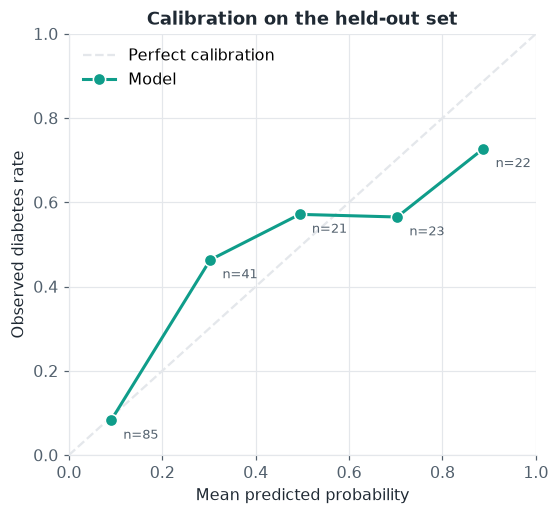

,predicted,observed,n
bin,,,
"(-0.001, 0.2]",0.090,0.082,85
"(0.2, 0.4]",0.303,0.463,41
"(0.4, 0.6]",0.494,0.571,21
"(0.6, 0.8]",0.703,0.565,23
"(0.8, 1.0]",0.888,0.727,22


In [19]:
cal = pd.DataFrame({"p": proba_test, "y": y_test.values})
cal["bin"] = pd.cut(cal.p, np.linspace(0, 1, 6), include_lowest=True)
cal_tab = cal.groupby("bin", observed=True).agg(predicted=("p", "mean"), observed=("y", "mean"), n=("y", "size"))

fig, ax = plt.subplots(figsize=(5.2, 4.8))
ax.plot([0, 1], [0, 1], color=GRID, lw=1.5, ls="--", label="Perfect calibration")
ax.plot(cal_tab.predicted, cal_tab.observed, color=TEAL, lw=2, marker="o", markersize=8, markeredgecolor="white", label="Model")
for _, r in cal_tab.iterrows():
    ax.annotate(f"n={int(r.n)}", (r.predicted, r.observed), xytext=(8, -12), textcoords="offset points", fontsize=8.5, color=MUTED)
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed diabetes rate")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left"); ax.set_title("Calibration on the held-out set")
finish(fig, "09_calibration.png")
cal_tab.round(3)

Predictions below 20 % are well calibrated (9 % predicted vs 8 % observed), which matters because that is the group a
clinic would reassure and de-prioritise. In the middle bins the model slightly **under-estimates** risk and at the top it
**over-estimates**, with wide uncertainty given only ~20 patients per bin. With 192 test patients this is acceptable;
in production the score would be recalibrated on local data before probabilities were shown to clinicians.

## 6. Patient risk stratification

The most useful output for a care team is not a probability but a **tier** that maps to an action. Using the
held-out patients, three tiers are defined on the predicted probability:

| Tier | Predicted probability | Suggested action |
|---|---|---|
| Low | < 20 % | Routine care; re-screen in 3 years |
| Moderate | 20–50 % | Lifestyle counselling, repeat OGTT / HbA1c within 12 months |
| High | ≥ 50 % | Enrol in a structured diabetes-prevention programme; confirmatory testing now |

In [20]:
tiers = pd.cut(proba_test, [0, 0.2, 0.5, 1.0], labels=["Low (<20%)", "Moderate (20–50%)", "High (≥50%)"], include_lowest=True)
tier_tab = (pd.DataFrame({"tier": tiers, "y": y_test.values}).groupby("tier", observed=True).y
            .agg(patients="size", cases="sum", observed_prevalence="mean"))
tier_tab["share_of_cohort"] = tier_tab.patients / tier_tab.patients.sum()
tier_tab["share_of_all_cases"] = tier_tab.cases / tier_tab.cases.sum()
tier_tab.round(3)

,patients,cases,observed_prevalence,share_of_cohort,share_of_all_cases
tier,,,,,
Low (<20%),85,7,0.082,0.443,0.104
Moderate (20–50%),53,26,0.491,0.276,0.388
High (≥50%),54,34,0.630,0.281,0.507


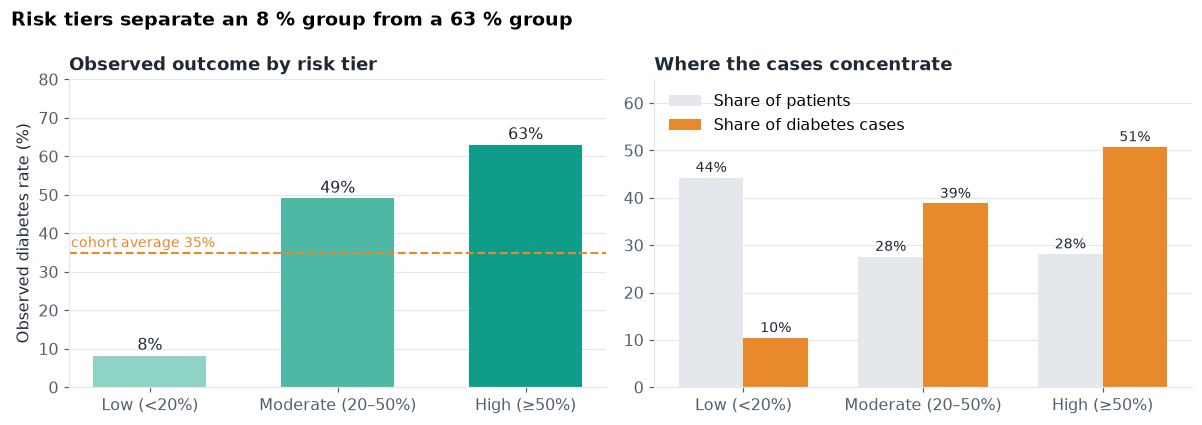

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
x = np.arange(len(tier_tab)); tier_colors = ["#8fd3c7", "#4fb8a5", TEAL]

bars = axes[0].bar(x, tier_tab.observed_prevalence * 100, color=tier_colors, width=0.6)
for b, v in zip(bars, tier_tab.observed_prevalence):
    axes[0].text(b.get_x() + b.get_width() / 2, v * 100 + 1.5, f"{v:.0%}", ha="center", color=INK)
axes[0].axhline(y_test.mean() * 100, color=ORANGE, lw=1.4, ls="--")
axes[0].text(-0.42, y_test.mean() * 100 + 1.5, f"cohort average {y_test.mean():.0%}", color=ORANGE, fontsize=9, ha="left")
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_tab.index); axes[0].set_ylim(0, 80); axes[0].grid(axis="x", visible=False)
axes[0].set_ylabel("Observed diabetes rate (%)"); axes[0].set_title("Observed outcome by risk tier", loc="left")

w = 0.36
axes[1].bar(x - w / 2, tier_tab.share_of_cohort * 100, width=w, color=GRID, label="Share of patients")
axes[1].bar(x + w / 2, tier_tab.share_of_all_cases * 100, width=w, color=ORANGE, label="Share of diabetes cases")
for i, (a, b) in enumerate(zip(tier_tab.share_of_cohort, tier_tab.share_of_all_cases)):
    axes[1].text(i - w / 2, a * 100 + 1.2, f"{a:.0%}", ha="center", fontsize=9, color=INK)
    axes[1].text(i + w / 2, b * 100 + 1.2, f"{b:.0%}", ha="center", fontsize=9, color=INK)
axes[1].set_xticks(x); axes[1].set_xticklabels(tier_tab.index); axes[1].set_ylim(0, 65); axes[1].grid(axis="x", visible=False)
axes[1].legend(loc="upper left"); axes[1].set_title("Where the cases concentrate", loc="left")
fig.suptitle("Risk tiers separate an 8 % group from a 63 % group", fontweight="bold", x=0.01, ha="left")
finish(fig, "10_risk_tiers.png")

**What the tiers deliver.** The 44 % of patients in the Low tier have an observed diabetes rate of 8 %, while the
28 % in the High tier have a rate of 63 %, an almost eight-fold separation from eight routine measurements. Just over
half of all future cases sit in the High tier and 90 % sit in the High or Moderate tiers, so a programme that targets
the top two tiers (56 % of patients) would reach nine out of ten future cases.

## 7. Individual risk scoring: example patients

In [22]:
examples = pd.DataFrame([
    {"Pregnancies": 1, "Glucose": 92,  "BloodPressure": 68, "SkinThickness": 22, "Insulin": 80,  "BMI": 23.5, "DiabetesPedigreeFunction": 0.25, "Age": 26},
    {"Pregnancies": 3, "Glucose": 128, "BloodPressure": 78, "SkinThickness": 30, "Insulin": 130, "BMI": 31.0, "DiabetesPedigreeFunction": 0.45, "Age": 38},
    {"Pregnancies": 6, "Glucose": 168, "BloodPressure": 84, "SkinThickness": 35, "Insulin": np.nan, "BMI": 37.2, "DiabetesPedigreeFunction": 0.90, "Age": 47},
], index=["Patient A – normal glucose, lean, young", "Patient B – impaired glucose, obese I", "Patient C – high glucose, obese II, family history"])

examples["risk_probability"] = model.predict_proba(examples[FEATURES])[:, 1].round(3)
examples["tier"] = pd.cut(examples.risk_probability, [0, 0.2, 0.5, 1.0], labels=["Low", "Moderate", "High"])
examples[["Glucose", "BMI", "Age", "Pregnancies", "DiabetesPedigreeFunction", "risk_probability", "tier"]]

,Glucose,BMI,Age,Pregnancies,DiabetesPedigreeFunction,risk_probability,tier
"Patient A – normal glucose, lean, young",92,23.5,26,1,0.25,0.029,Low
"Patient B – impaired glucose, obese I",128,31.0,38,3,0.45,0.289,Moderate
"Patient C – high glucose, obese II, family history",168,37.2,47,6,0.90,0.884,High


Patient C illustrates a practical strength of the pipeline: their insulin value is missing (as it is for half the
cohort), the imputer fills it with the training median, and the score is still produced. In a real deployment the
missing-value rate per feature would be monitored so that a drift in what gets measured does not silently degrade
the score.

## 8. Findings and recommendations

### Key findings

1. **Data quality is the first clinical risk.** Five lab columns encode "not measured" as 0; insulin is missing for 49 %
   of patients and skin-fold for 30 %. Recoding to missing and imputing inside the model pipeline retained all 768
   patients without biasing the model toward impossible values.
2. **Glucose dominates.** Diabetes prevalence rises from 7 % (2-h glucose < 100 mg/dL) to 59 % (≥ 126 mg/dL). In the
   adjusted model a one-SD (30 mg/dL) increase multiplies the odds by 3.3.
3. **BMI is an independent, modifiable driver.** OR 2.1 per 6.8 kg/m², with prevalence of 7 % in normal-weight patients
   against 44–48 % in obese patients.
4. **Age is mostly a proxy.** Its crude effect disappears once glucose, BMI and pregnancy history are accounted for.
5. **A simple, transparent model performs well.** Cross-validated AUC 0.83, held-out AUC 0.82, with a well-calibrated
   low-risk band.
6. **Three tiers make the score actionable.** Low tier: 8 % observed risk; High tier: 63 %. Targeting the top two tiers
   reaches 90 % of future cases.

### Recommendations for a care team

* **Adopt a screening threshold of 0.30**, not 0.50: sensitivity rises from 51 % to 78 % for a modest increase in
  follow-up workload.
* **Prioritise OGTT / HbA1c confirmation and weight-management referral for the High tier**, and lifestyle counselling
  with a 12-month recheck for the Moderate tier.
* **Fix data capture upstream.** A form that stores "not measured" as 0 corrupts every downstream analysis; recording
  nulls explicitly is a cheap, high-value change.
* **Do not drop insulin from the panel purely on missingness.** It adds little to this model, but its absence in half the
  cohort limits what can be concluded about it.

### Limitations

* The cohort is female, of a single ethnic background and from a single study, so coefficients will not transfer
  unchanged to a general clinic population; the method does, the numbers need local recalibration.
* 768 patients and 192 in the test set give wide confidence intervals on the calibration curve and on the weaker
  predictors.
* The outcome is a five-year diagnosis, so the model is a prognostic score rather than a diagnostic test.
* Missingness in insulin and skin-fold was assumed to be uninformative after checking it was only weakly related to
  outcome; a sensitivity analysis with a missing-indicator would strengthen that assumption.